# 사출 불량 예측: 변수 구성과 랜덤포레스트 개선 실험

기존 분석과 시계열 비교에 이어 **변수 구성 비교 → RF 튜닝 → 임계값 선택 → 기존 모델과 지표 비교**를 수행한다. 새로운 모델 종류나 대규모 탐색은 추가하지 않는다. 이전 평가 결과를 알고 시작한 후속 탐색 실험이며, 새로운 미사용 최종 시험이 아니다.

**선택 규칙을 먼저 고정한다.**

1. 변수/모델 설정: 10월 22일·23일을 각각 검증하는 두 확장 학습 fold의 평균 AP로 선택.
2. 임계값: 10월 27~31일에서 검사 대상 10% 이내로 F1 최대화. 동률이면 FP 최소, 다음 높은 임계값.
3. 결과 보고: 기존과 같은 11월 1~6일 기록. 이 구간의 지표로 재선택하지 않는다.

불량 날짜가 적어 개발 fold는 2개뿐이며 모두 RG3 구간이다. 임계값 조정 구간은 CN7뿐이다. 제품 구성 편향과 적은 불량 표본은 그대로 기록한다. 개선을 보장하지 않는다.

CPU 노트북이다. labeled_data.csv를 연결하고 아래 DATA_PATH를 지정한다. Drive를 쓰면 먼저 별도 셀에서 `from google.colab import drive; drive.mount('/content/drive')`를 실행한다. 원본 데이터는 포함하지 않았다.

In [1]:
# 일반적인 코랩/캐글 환경에는 아래 패키지가 준비되어 있다.
# import 오류가 있는 경우에만 다음 줄의 주석을 해제해 실행한다.
# %pip install pandas numpy scikit-learn matplotlib
from pathlib import Path
import os, sys, json, hashlib, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, confusion_matrix, precision_recall_curve
from sklearn.inspection import permutation_importance

SEED = 42
INSPECTION_BUDGET = 0.10  # 검증 데이터의 10% 이내. 현장 요구가 아닌 분석용 가정.
DATA_PATH = None  # 예: '/content/labeled_data.csv'
if DATA_PATH is None:
    candidates = [Path('labeled_data.csv'), Path('dataset/labeled_data.csv'),
                  Path('/content/labeled_data.csv')]
    if os.environ.get('MOLDING_DATA_PATH'):
        candidates.insert(0, Path(os.environ['MOLDING_DATA_PATH']))
    if Path('/kaggle/input').exists():
        candidates.extend(Path('/kaggle/input').rglob('labeled_data.csv'))
    existing = list(dict.fromkeys(p.resolve() for p in candidates if p.is_file()))
    if len(existing) == 1:
        DATA_PATH = existing[0]
    elif len(existing) > 1:
        raise ValueError('동명 파일이 여러 개입니다. DATA_PATH를 직접 지정하세요.')
    elif 'google.colab' in sys.modules:
        from google.colab import files
        uploaded = files.upload()
        if 'labeled_data.csv' not in uploaded:
            raise ValueError('labeled_data.csv를 업로드하세요.')
        DATA_PATH = Path('labeled_data.csv')
    else:
        raise FileNotFoundError('labeled_data.csv를 연결하고 DATA_PATH를 지정하세요.')
DATA_PATH = Path(DATA_PATH)
raw = pd.read_csv(DATA_PATH, dtype={'PART_FACT_SERIAL': str})
print('Python:', platform.python_version(), 'pandas:', pd.__version__, 'sklearn:', sklearn.__version__)
print('파일:', DATA_PATH.name, '행/열:', raw.shape)
source_sha256 = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
print('SHA256:', source_sha256)
display(raw[['TimeStamp','PART_NAME','PassOrFail','Injection_Time','Max_Injection_Pressure']].head())

Python: 3.12.14 pandas: 3.0.5 sklearn: 1.9.0
파일: labeled_data.csv 행/열: (7996, 45)
SHA256: e8d375c8e0c2cdfc309baf01ac2203fc2edb6e9728e836119042f9670cd46b51


,TimeStamp,PART_NAME,PassOrFail,Injection_Time,Max_Injection_Pressure
0,2020-10-16 04:57:47,CN7 W/S SIDE MLD'G RH,Y,9.59,141.800003
1,2020-10-16 04:58:48,CN7 W/S SIDE MLD'G RH,Y,9.60,141.800003
2,2020-10-16 04:58:48,CN7 W/S SIDE MLD'G LH,Y,9.60,141.800003
3,2020-10-16 04:59:48,CN7 W/S SIDE MLD'G LH,Y,9.59,141.800003
4,2020-10-16 04:59:48,CN7 W/S SIDE MLD'G RH,Y,9.59,141.800003


## 1. 시간 구조와 이력 구간

완전 중복을 제거하고 S14의 CN7/RG3만 남긴다. 원본 Y/N을 불량 1/양품 0으로 매핑한다. 시간과 ID로 정렬한다.

같은 설비·제품 안에서도 **날짜, 생산 지시일/코드가 바뀌거나 관측 간격이 30분을 넘으면** 새 이력 구간으로 시작한다. 30분은 전체 기록의 통상 간격(약 60초)보다 충분히 긴 공백을 구분하기 위한 사전 분석 가정이며, 실제 공장 가동·정지 기준이 아니다. 성능 점수에 맞춰 조정하지 않는다. 제품별로 구분하므로 다른 제품의 값은 이력에 섞지 않는다.

원본/분석 행: 7996 5230 불량: 60 이력 구간: 33


,gap_seconds
count,5.226000e+03
mean,1.117077e+03
std,2.509335e+04
min,3.000000e+00
50%,6.000000e+01
90%,6.200000e+01
95%,6.300000e+01
99%,1.240000e+02
max,1.027162e+06


동일 제품의 30분 초과 공백: 25


count  sum
time       PART_NAME                        
2020-10-16 CN7 W/S SIDE MLD'G LH    187    4
           CN7 W/S SIDE MLD'G RH    188   13
2020-10-19 CN7 W/S SIDE MLD'G LH     36    0
           CN7 W/S SIDE MLD'G RH     36    0
2020-10-20 CN7 W/S SIDE MLD'G LH    382    0
           CN7 W/S SIDE MLD'G RH    382    0
2020-10-21 RG3 MOLD'G W/SHLD, LH     41    0
           RG3 MOLD'G W/SHLD, RH     41    0
2020-10-22 RG3 MOLD'G W/SHLD, LH    300    0
           RG3 MOLD'G W/SHLD, RH    300   15
2020-10-23 RG3 MOLD'G W/SHLD, LH    250    0
           RG3 MOLD'G W/SHLD, RH    250   10
2020-10-27 CN7 W/S SIDE MLD'G LH    314    5
           CN7 W/S SIDE MLD'G RH    314    5
2020-10-29 CN7 W/S SIDE MLD'G LH    227    0
           CN7 W/S SIDE MLD'G RH    227    0
2020-10-30 CN7 W/S SIDE MLD'G LH    376    0
           CN7 W/S SIDE MLD'G RH    379    0
2020-11-03 CN7 W/S SIDE MLD'G LH    463    1
           CN7 W/S SIDE MLD'G RH    463    0
2020-11-04 RG3 MOLD'G W/SHLD, LH     35    5
           RG3 MOLD'G W/SHLD, RH     36    2
2020-11-05 RG3 MOLD'G W/SHLD, LH      1    0
           RG3 MOLD'G W/SHLD, RH      1    0
2020-11-06 RG3 MOLD'G W/SHLD, LH      1    0

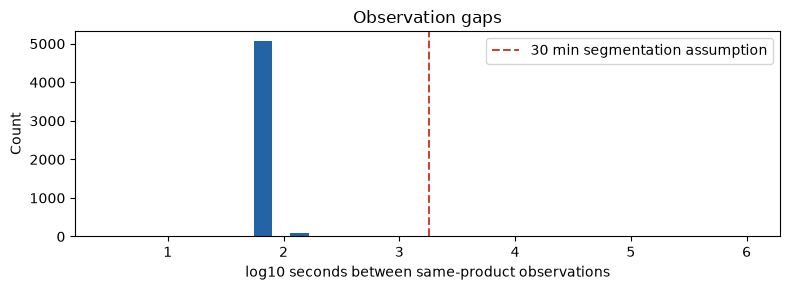

In [2]:
raw_n = len(raw)
df=raw.drop_duplicates().copy()
assert not df._id.duplicated().any()
df=df.loc[df.EQUIP_CD.eq('S14') & df.PART_NAME.str.startswith(('CN7','RG3'))].copy()
df['time']=pd.to_datetime(df.TimeStamp)
df['defect']=df.PassOrFail.map({'Y':0,'N':1}).astype(int)
df=df.sort_values(['time','_id']).reset_index(drop=True)
GROUP=['EQUIP_CD','PART_NAME']
g=df.groupby(GROUP,sort=False)
df['gap_seconds']=g.time.diff().dt.total_seconds()
date=df.time.dt.date
previous_date=g.time.shift().dt.date
new_segment=(df.gap_seconds.isna() | df.gap_seconds.gt(1800) | date.ne(previous_date)
    | df.PART_FACT_PLAN_DATE.ne(g.PART_FACT_PLAN_DATE.shift())
    | df.PART_FACT_SERIAL.ne(g.PART_FACT_SERIAL.shift()))
segment_number=new_segment.groupby([df.EQUIP_CD,df.PART_NAME],sort=False).cumsum()
df['segment']=pd.factorize(pd.MultiIndex.from_arrays([df.EQUIP_CD,df.PART_NAME,segment_number]))[0]
assert df.groupby('segment').PART_NAME.nunique().max()==1
assert df.groupby('segment').EQUIP_CD.nunique().max()==1
print('원본/분석 행:',raw_n,len(df),'불량:',int(df.defect.sum()),'이력 구간:',df.segment.nunique())
display(df.gap_seconds.describe(percentiles=[.5,.9,.95,.99]).to_frame())
print('동일 제품의 30분 초과 공백:',int(df.gap_seconds.gt(1800).sum()))
daily=df.groupby([df.time.dt.date,'PART_NAME']).defect.agg(['count','sum'])
display(daily)
numeric=list(raw.columns[raw.columns.get_loc('Injection_Time'):])
assert all(pd.api.types.is_numeric_dtype(df[c]) for c in numeric)
assert 'Reason' not in numeric
fig,ax=plt.subplots(figsize=(8,3))
gap=df.gap_seconds.dropna()
ax.hist(np.log10(gap),bins=35,color='#2463a6')
ax.axvline(np.log10(1800),color='#c44835',linestyle='--',label='30 min segmentation assumption')
ax.set(xlabel='log10 seconds between same-product observations',ylabel='Count',title='Observation gaps')
ax.legend(); fig.tight_layout(); plt.show()

## 2. 과거만 사용하는 시계열 변수

각 수치 변수에서 현재값-직전값, **현재 건을 제외한** 직전 5·10건 평균과 표준편차를 생성한다. `shift(1)` 후 rolling을 적용한다. 평균은 최소 1개, 표준편차는 최소 2개의 과거 관측을 요구하고 부족하면 결측으로 남긴다. 5·10건의 가용 이력 개수도 입력한다. 구간 첫 기록은 과거가 없고, 학습 구간에서만 맞춘 결측 대체를 사용한다.

현재 공정값은 사이클 종료 후 얻을 수 있다는 기존 가정이다. 실제 불량 라벨은 어떤 과거 특성에도 사용하지 않는다. 평가 중 이전 시각의 공정값은 사용할 수 있다는 순차 추론 시나리오다. 평가 라벨로 재학습하지 않는다.

In [3]:
def make_history(frame):
    hist={}
    for c in numeric:
        groups=frame.groupby('segment',sort=False)[c]
        hist[c+'__delta1']=frame[c]-groups.shift(1)
        for w in (5,10):
            hist[c+f'__past{w}_mean']=groups.transform(lambda x:x.shift(1).rolling(w,min_periods=1).mean())
            hist[c+f'__past{w}_std']=groups.transform(lambda x:x.shift(1).rolling(w,min_periods=2).std())
    previous_count=frame.groupby('segment',sort=False).cumcount()
    for w in (5,10): hist[f'history_count_{w}']=previous_count.clip(upper=w)
    return pd.DataFrame(hist,index=frame.index)
hist=make_history(df)
extended=pd.concat([df,hist],axis=1)
assert df.groupby('segment').time.diff().dropna().gt(pd.Timedelta(0)).all()
first=df.groupby('segment').head(1).index
assert hist.loc[first,[c for c in hist if not c.startswith('history_count')]].isna().all().all()
# 독립 확인: 한 개 창의 평균을 원래 과거 기록에서 직접 재계산한다.
segment=df.segment.value_counts().idxmax()
idx=df.index[df.segment.eq(segment)][10]
previous=df.loc[(df.segment.eq(segment)) & (df.time < df.loc[idx,'time'])].tail(5)
assert np.isclose(hist.loc[idx,'Injection_Time__past5_mean'],previous.Injection_Time.mean())
# 미래 센서값을 바꿔도 이전 시점의 이력 특성이 변하지 않는지 확인한다.
cut=df.time.quantile(.6)
changed=df.copy()
changed.loc[changed.time>cut,numeric]=changed.loc[changed.time>cut,numeric]*1.1+17
changed_hist=make_history(changed)
pd.testing.assert_frame_equal(hist.loc[df.time<=cut],changed_hist.loc[df.time<=cut])
display(hist[['history_count_5','history_count_10']].describe())
display(extended[['time','PART_NAME','Injection_Time','Injection_Time__delta1',
                  'Injection_Time__past5_mean','history_count_5']].head(12))
print('이력 없는 기록 비율:',float(hist.history_count_5.eq(0).mean()))
print('미래 값 변경 불변성, 구간 경계, 과거 평균 직접 계산 확인 완료')

,history_count_5,history_count_10
count,5230.000000,5230.000000
mean,4.911090,9.678776
std,0.567437,1.470715
min,0.000000,0.000000
25%,5.000000,10.000000
50%,5.000000,10.000000
75%,5.000000,10.000000
max,5.000000,10.000000


,time,PART_NAME,Injection_Time,Injection_Time__delta1,Injection_Time__past5_mean,history_count_5
0,2020-10-16 04:57:47,CN7 W/S SIDE MLD'G RH,9.59,NaN,NaN,0
1,2020-10-16 04:58:48,CN7 W/S SIDE MLD'G RH,9.60,0.010000,9.590000,1
2,2020-10-16 04:58:48,CN7 W/S SIDE MLD'G LH,9.60,NaN,NaN,0
3,2020-10-16 04:59:48,CN7 W/S SIDE MLD'G LH,9.59,-0.010000,9.600000,1
4,2020-10-16 04:59:48,CN7 W/S SIDE MLD'G RH,9.59,-0.010000,9.595000,2
5,2020-10-16 05:00:46,CN7 W/S SIDE MLD'G RH,9.58,-0.010000,9.593334,3
6,2020-10-16 05:00:46,CN7 W/S SIDE MLD'G LH,9.58,-0.010000,9.595000,2
7,2020-10-16 05:01:46,CN7 W/S SIDE MLD'G RH,9.58,0.000000,9.590000,4
8,2020-10-16 05:01:46,CN7 W/S SIDE MLD'G LH,9.58,0.000000,9.590000,3
9,2020-10-16 05:02:46,CN7 W/S SIDE MLD'G RH,9.57,-0.010000,9.588000,5


이력 없는 기록 비율: 0.006309751434034417
미래 값 변경 불변성, 구간 경계, 과거 평균 직접 계산 확인 완료


## 3. 개선 실험용 분리와 지표

| 개발 fold | 학습 | 설정 비교용 검증 |
|---|---|---|
| D1 | 10월 22일 이전 | 10월 22일 |
| D2 | 10월 23일 이전 | 10월 23일 |

두 fold에서 설정 선택 후 10월 27일 이전 전체로 다시 학습한다. 10월 27~31일은 판정 기준 조정, 11월은 보고용 평가다. 동일 생산 묶음·이력 구간의 구간 중복과 미래 정보 누수를 확인한다.

AP는 Average Precision이다. Precision/Recall/F1은 임계값에 의존하고 AP/ROC-AUC는 점수 순위 지표다. 두 종류를 구분한다. 부트스트랩 신뢰구간이나 유의성을 주장하지 않는다.

In [4]:
from itertools import product
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, balanced_accuracy_score
from sklearn.base import clone
DEV=[('D1','2020-10-22','2020-10-23'),('D2','2020-10-23','2020-10-24')]
tr=extended.loc[extended.time.lt('2020-10-27')].copy()
cal=extended.loc[extended.time.ge('2020-10-27') & extended.time.lt('2020-11-01')].copy()
evaluation=extended.loc[extended.time.ge('2020-11-01')].copy()
def keys(f):
    return set(f[['PART_FACT_PLAN_DATE','PART_FACT_SERIAL','EQUIP_CD']].astype(str).agg('|'.join,axis=1))
split_rows=[]
for name,start,end in DEV:
    a=extended.loc[extended.time.lt(start)]; b=extended.loc[extended.time.ge(start)&extended.time.lt(end)]
    assert a.defect.nunique()==b.defect.nunique()==2
    assert keys(a).isdisjoint(keys(b)) and set(a.segment).isdisjoint(b.segment)
    assert a.time.max()<b.time.min()
    for label,x in [('train',a),('validation',b)]:
        split_rows.append(dict(split=name+'_'+label,rows=len(x),defects=int(x.defect.sum()),products=', '.join(sorted(x.PART_NAME.unique()))))
for label,x in [('refit_train',tr),('threshold',cal),('evaluation',evaluation)]:
    split_rows.append(dict(split=label,rows=len(x),defects=int(x.defect.sum()),products=', '.join(sorted(x.PART_NAME.unique()))))
for a,b in [(tr,cal),(tr,evaluation),(cal,evaluation)]:
    assert keys(a).isdisjoint(keys(b)) and set(a.segment).isdisjoint(b.segment)
    assert a.time.max()<b.time.min()
display(pd.DataFrame(split_rows))
BASE=dict(n_estimators=200,max_depth=6,min_samples_leaf=5,class_weight='balanced_subsample',random_state=42,n_jobs=2)
def pipeline(columns,params):
    pre=ColumnTransformer([
      ('num',Pipeline([('impute',SimpleImputer(strategy='median')),('scale',StandardScaler())]),columns),
      ('part',OneHotEncoder(handle_unknown='ignore',sparse_output=False),['PART_NAME'])])
    return Pipeline([('preprocess',pre),('model',RandomForestClassifier(**params))])
def fit(frame,candidates,params):
    cols=[c for c in candidates if frame[c].nunique(dropna=True)>1]
    used=cols+['PART_NAME']
    model=pipeline(cols,params).fit(frame[used],frame.defect)
    return model,used
def cv(candidates,params):
    values=[]
    for name,start,end in DEV:
        a=extended.loc[extended.time.lt(start)]; b=extended.loc[extended.time.ge(start)&extended.time.lt(end)]
        m,use=fit(a,candidates,params)
        values.append(float(average_precision_score(b.defect,m.predict_proba(b[use])[:,1])))
    return {'D1_AP':values[0],'D2_AP':values[1],'mean_AP':float(np.mean(values)),'min_AP':min(values)}
def metrics(y,s,t):
    pred=np.asarray(s)>=t
    tn,fp,fn,tp=confusion_matrix(y,pred,labels=[0,1]).ravel()
    return dict(TP=int(tp),FN=int(fn),FP=int(fp),TN=int(tn),
        inspections=int(tp+fp),inspection_rate=float((tp+fp)/len(y)),
        precision=float(tp/(tp+fp)) if tp+fp else 0.,recall=float(tp/(tp+fn)),
        F1=float(f1_score(y,pred,zero_division=0)),accuracy=float(accuracy_score(y,pred)),
        balanced_accuracy=float(balanced_accuracy_score(y,pred)))
def select_threshold(y,s,objective='F1'):
    candidates=np.r_[np.nextafter(max(s),np.inf),np.unique(s)]
    rows=[]
    for t in candidates:
        pred=s>=t; tp=int(((np.asarray(y)==1)&pred).sum()); fp=int(((np.asarray(y)==0)&pred).sum()); fn=int(np.sum(y)-tp)
        rows.append(dict(threshold=float(t),TP=tp,FP=fp,F1=2*tp/(2*tp+fp+fn) if 2*tp+fp+fn else 0.,inspection_rate=(tp+fp)/len(y)))
    table=pd.DataFrame(rows)
    selected=table.loc[table.inspection_rate<=.10].sort_values([objective,'FP','threshold'],ascending=[False,True,False]).iloc[0]
    return float(selected.threshold),table
print('설정 선택은 10월 22~23일, 기준 조정은 10월 27~31일로 분리했습니다.')

,split,rows,defects,products
0,D1_train,1293,17,"CN7 W/S SIDE MLD'G LH, CN7 W/S SIDE MLD'G RH, ..."
1,D1_validation,600,15,"RG3 MOLD'G W/SHLD, LH, RG3 MOLD'G W/SHLD, RH"
2,D2_train,1893,32,"CN7 W/S SIDE MLD'G LH, CN7 W/S SIDE MLD'G RH, ..."
3,D2_validation,500,10,"RG3 MOLD'G W/SHLD, LH, RG3 MOLD'G W/SHLD, RH"
4,refit_train,2393,42,"CN7 W/S SIDE MLD'G LH, CN7 W/S SIDE MLD'G RH, ..."
5,threshold,1837,10,"CN7 W/S SIDE MLD'G LH, CN7 W/S SIDE MLD'G RH"
6,evaluation,1000,8,"CN7 W/S SIDE MLD'G LH, CN7 W/S SIDE MLD'G RH, ..."


설정 선택은 10월 22~23일, 기준 조정은 10월 27~31일로 분리했습니다.


## 4. 변수 구성 비교

- current_only: 현재 공정값 + 제품명
- compact_history: 현재 값 + 쿠션 위치/가소화 시간/평균 배압의 과거 5·10건 평균·표준편차/직전 차이 + 이력 개수
- all_history: 현재 값 + 모든 수치 변수의 과거 특성 + 이력 개수

축소 변수 3개는 이전 탐색에서 본 후보이므로 완전히 사전 독립 선택은 아니다. 여기서 새로운 평가 결과로 후보를 다시 바꾸지 않는다. 고정 RF 설정으로 평균 개발 AP 최대 구성을 선택한다. 동률이면 변수 수가 적은 구성을 선택한다.

In [5]:
focus=['Cushion_Position','Plasticizing_Time','Average_Back_Pressure']
compact=[c for c in hist if any(c.startswith(f+'__') for f in focus) or c.startswith('history_count')]
SETS={'current_only':numeric,'compact_history':numeric+compact,'all_history':numeric+list(hist.columns)}
feature_rows=[]
for name,candidates in SETS.items():
    row={'features':name,'candidate_count':len(candidates)+1,**cv(candidates,BASE)}
    feature_rows.append(row); print(name,row['mean_AP'])
feature_results=pd.DataFrame(feature_rows).sort_values(['mean_AP','candidate_count'],ascending=[False,True])
selected_features=feature_results.iloc[0]['features']
display(feature_results)
print('선택한 변수 구성:',selected_features)

current_only 0.045805434908763466


compact_history 0.03687920630973178


all_history 0.03708910729948574


,features,candidate_count,D1_AP,D2_AP,mean_AP,min_AP
0,current_only,37,0.024231,0.067380,0.045805,0.024231
2,all_history,219,0.030010,0.044169,0.037089,0.030010
1,compact_history,54,0.028102,0.045657,0.036879,0.028102


선택한 변수 구성: current_only


## 5. RF 제한 탐색

선택한 변수 구성에서 깊이 3/6/제한 없음 × 최소 잎 표본 5/15 × 가중치 없음/balanced_subsample의 **12개 설정**을 같은 두 개발 fold에서 비교한다. 트리 수는 200으로 고정한다. 평균 AP 최대, 동률이면 최소 fold AP가 높은 설정을 선택하고 추가 동률은 미리 정한 탐색 순서로 결정한다. 평가 지표가 나쁘다고 탐색 범위를 확장하지 않는다.

In [6]:
tuning_rows=[]; settings={}
for i,(depth,leaf,weight) in enumerate(product([3,6,None],[5,15],[None,'balanced_subsample'])):
    params={**BASE,'max_depth':depth,'min_samples_leaf':leaf,'class_weight':weight}
    settings[i]=params
    row={'id':i,'max_depth':str(depth),'min_samples_leaf':leaf,'class_weight':str(weight),**cv(SETS[selected_features],params)}
    tuning_rows.append(row); print('설정',i,'mean AP',round(row['mean_AP'],4))
tuning_results=pd.DataFrame(tuning_rows).sort_values(['mean_AP','min_AP','id'],ascending=[False,False,True])
selected_id=int(tuning_results.iloc[0]['id']); selected_params=settings[selected_id]
display(tuning_results)
print('고정한 설정:',selected_params)
print('평가 결과를 보기 전에 설정 선택을 완료했습니다.')

설정 0 mean AP 0.0373


설정 1 mean AP 0.0524


설정 2 mean AP 0.0344


설정 3 mean AP 0.0347


설정 4 mean AP 0.0411


...

설정 9 mean AP 0.0771


설정 10 mean AP 0.0625


설정 11 mean AP 0.0756


,id,max_depth,min_samples_leaf,class_weight,D1_AP,D2_AP,mean_AP,min_AP
9,9,None,5,balanced_subsample,0.024231,0.129919,0.077075,0.024231
11,11,None,15,balanced_subsample,0.020144,0.130959,0.075552,0.020144
10,10,None,15,None,0.023962,0.101106,0.062534,0.023962
1,1,3,5,balanced_subsample,0.048333,0.056502,0.052417,0.048333
8,8,None,5,None,0.025000,0.070133,0.047566,0.025000
6,6,6,15,None,0.021887,0.072172,0.047029,0.021887
5,5,6,5,balanced_subsample,0.024231,0.067380,0.045805,0.024231
7,7,6,15,balanced_subsample,0.024010,0.066420,0.045215,0.024010
4,4,6,5,None,0.025294,0.056810,0.041052,0.025294
0,0,3,5,None,0.026596,0.048043,0.037319,0.026596


고정한 설정: {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 5, 'class_weight': 'balanced_subsample', 'random_state': 42, 'n_jobs': 2}
평가 결과를 보기 전에 설정 선택을 완료했습니다.


## 6. 임계값 선택

설정 선택 후 학습 기간 전체로 재학습한다. 별도 10월 27~31일 구간에서 **검사 대상 10% 이내 F1 최대** 기준을 선택한다. F1은 정밀도·재현율의 조화평균이며 실제 검사 비용 함수가 아니다. 따라서 이후 검사 수를 함께 보고한다.

기존 모델도 같은 F1 규칙을 적용해 공정하게 비교한다. 원래 TP 최대 규칙과 기본 0.5도 보조 기준으로 함께 보고하되, 평가를 보고 가장 좋은 행으로 주 기준을 바꾸지 않는다. 선택 모델은 baseline, 변수 변경만, 변수+튜닝의 세 단계로 구분한다.

In [7]:
fit_specs={'baseline':(SETS['current_only'],BASE),
           'features_only':(SETS[selected_features],BASE),
           'tuned':(SETS[selected_features],selected_params)}
fitted={}; policies=[]
for name,(features,params) in fit_specs.items():
    m,use=fit(tr,features,params)
    score=m.predict_proba(cal[use])[:,1]
    threshold,curve=select_threshold(cal.defect,score,'F1')
    fitted[name]=(m,use,threshold)
    policies.append(dict(model=name,policy='F1_cap10',threshold=threshold,AP=float(average_precision_score(cal.defect,score)),**metrics(cal.defect,score,threshold)))
    if name=='baseline':
        old_threshold,_=select_threshold(cal.defect,score,'TP')
threshold_results=pd.DataFrame(policies)
display(threshold_results)
print('임계값 고정 완료. 이후 평가를 이용한 재선택은 하지 않습니다.')

,model,policy,threshold,AP,TP,FN,FP,TN,inspections,inspection_rate,precision,recall,F1,accuracy,balanced_accuracy
0,baseline,F1_cap10,0.171032,0.180517,2,8,1,1826,3,0.001633,0.666667,0.2,0.307692,0.995101,0.599726
1,features_only,F1_cap10,0.171032,0.180517,2,8,1,1826,3,0.001633,0.666667,0.2,0.307692,0.995101,0.599726
2,tuned,F1_cap10,0.104802,0.145197,2,8,1,1826,3,0.001633,0.666667,0.2,0.307692,0.995101,0.599726


임계값 고정 완료. 이후 평가를 이용한 재선택은 하지 않습니다.


## 7. 같은 평가 기록의 최종 지표 비교

여기서 최종은 이 실험의 마지막 보고 단계라는 의미이며 새 미사용 평가를 뜻하지 않는다. 주 비교는 baseline/F1_cap10 대 tuned/F1_cap10이다. 설정이 달라지면 점수 척도도 달라지므로 각 모델의 독립 조정 구간에서 임계값을 정했다.

,model,policy,threshold,AP,ROC_AUC,TP,FN,FP,TN,inspections,inspection_rate,precision,recall,F1,accuracy,balanced_accuracy
0,baseline,F1_cap10,0.171032,0.103929,0.914189,2,6,35,957,37,0.037,0.054054,0.250,0.088889,0.959,0.607359
1,baseline,default_0.5,0.500000,0.103929,0.914189,1,7,5,987,6,0.006,0.166667,0.125,0.142857,0.988,0.559980
2,baseline,original_TP_cap10,0.118960,0.103929,0.914189,2,6,35,957,37,0.037,0.054054,0.250,0.088889,0.959,0.607359
3,features_only,F1_cap10,0.171032,0.103929,0.914189,2,6,35,957,37,0.037,0.054054,0.250,0.088889,0.959,0.607359
4,features_only,default_0.5,0.500000,0.103929,0.914189,1,7,5,987,6,0.006,0.166667,0.125,0.142857,0.988,0.559980
5,tuned,F1_cap10,0.104802,0.119452,0.893964,2,6,30,962,32,0.032,0.062500,0.250,0.100000,0.964,0.609879
6,tuned,default_0.5,0.500000,0.119452,0.893964,0,8,0,992,0,0.000,0.000000,0.000,0.000000,0.992,0.500000


,AP,ROC_AUC,precision,recall,F1,TP,FN,FP,inspections
model,,,,,,,,,
baseline,0.103929,0.914189,0.054054,0.25,0.088889,2,6,35,37
features_only,0.103929,0.914189,0.054054,0.25,0.088889,2,6,35,37
tuned,0.119452,0.893964,0.062500,0.25,0.100000,2,6,30,32


outcome                              FN  FP   TN  TP
model         PART_NAME                             
baseline      CN7 W/S SIDE MLD'G LH   1   0  462   0
              CN7 W/S SIDE MLD'G RH   0   0  463   0
              RG3 MOLD'G W/SHLD, LH   5   0   32   0
              RG3 MOLD'G W/SHLD, RH   0  35    0   2
features_only CN7 W/S SIDE MLD'G LH   1   0  462   0
              CN7 W/S SIDE MLD'G RH   0   0  463   0
              RG3 MOLD'G W/SHLD, LH   5   0   32   0
              RG3 MOLD'G W/SHLD, RH   0  35    0   2
tuned         CN7 W/S SIDE MLD'G LH   1   0  462   0
              CN7 W/S SIDE MLD'G RH   0   0  463   0
              RG3 MOLD'G W/SHLD, LH   5   0   32   0
              RG3 MOLD'G W/SHLD, RH   0  30    5   2

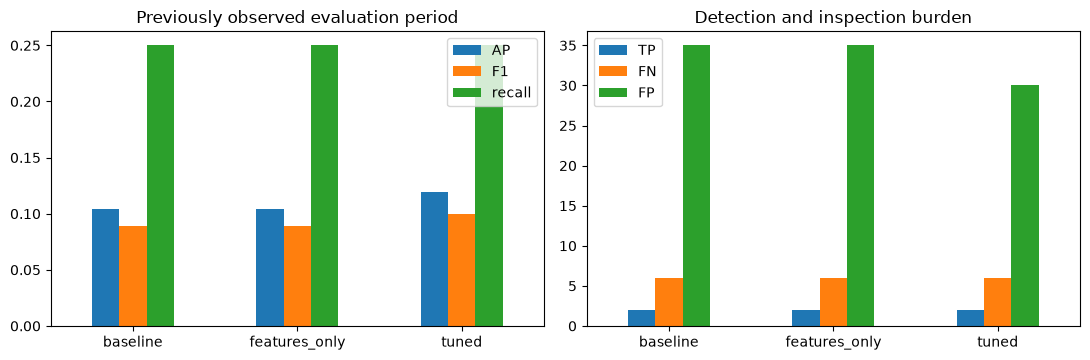

In [8]:
report=[]; predictions=[]
for name,(m,use,threshold) in fitted.items():
    score=m.predict_proba(evaluation[use])[:,1]
    choices={'F1_cap10':threshold,'default_0.5':.5}
    if name=='baseline': choices['original_TP_cap10']=old_threshold
    for policy,t in choices.items():
        report.append(dict(model=name,policy=policy,threshold=t,AP=float(average_precision_score(evaluation.defect,score)),
            ROC_AUC=float(roc_auc_score(evaluation.defect,score)),**metrics(evaluation.defect,score,t)))
    x=evaluation[['_id','time','PART_NAME','defect','Reason']].copy()
    x['model']=name;x['score']=score;x['pred']=(score>=threshold).astype(int)
    x['outcome']=np.select([x.defect.eq(1)&x.pred.eq(1),x.defect.eq(1)&x.pred.eq(0),x.defect.eq(0)&x.pred.eq(1)],['TP','FN','FP'],default='TN')
    predictions.append(x)
report=pd.DataFrame(report);predictions=pd.concat(predictions,ignore_index=True)
display(report)
assert all(report.TP+report.FN==8)
assert all(report[['TP','FN','FP','TN']].sum(axis=1)==1000)
primary=report.loc[report.policy.eq('F1_cap10')].set_index('model')
display(primary[['AP','ROC_AUC','precision','recall','F1','TP','FN','FP','inspections']])
display(predictions.groupby(['model','PART_NAME','outcome']).size().unstack(fill_value=0))
fig,axes=plt.subplots(1,2,figsize=(11,3.7))
primary[['AP','F1','recall']].plot.bar(ax=axes[0],rot=0)
axes[0].set_title('Previously observed evaluation period');axes[0].set_xlabel('')
primary[['TP','FN','FP']].plot.bar(ax=axes[1],rot=0)
axes[1].set_title('Detection and inspection burden');axes[1].set_xlabel('')
fig.tight_layout();plt.show()

## 저장된 개선 실험 결과와 판단

현재 공정값만 쓰는 구성이 선택됐다. 개발 평균 AP는 현재 값 0.0458, 전체 시계열 추가 0.0371, 일부 시계열 추가 0.0369였다. 12개 설정 중 깊이 제한 없음·최소 잎 표본 5·balanced_subsample이 선택되어 개발 평균 AP가 0.0771이 됐다. D1 AP는 그대로이고 D2에서 향상되어 기간 전체의 안정적 개선으로 볼 수 없다.

같은 평가 기록의 동일 F1 선택 규칙에서 AP 0.1039→0.1195, F1 0.0889→0.1000, FP 35→30으로 변했다. TP 2/FN 6은 그대로이고 ROC-AUC는 0.9142→0.8940으로 낮아졌다. 따라서 **불량 탐지를 유지하며 오탐 5건을 줄인 제한된 개선**이다. 높은 성능이나 현장 적용 수준에 도달했다고 판단하지 않는다.

AP와 ROC-AUC는 각각 PR 관점과 전체 순위 관점을 요약하며 같은 방향으로 변할 필요가 없다. 평가 불량은 8건뿐이다. 개발 평균 AP도 2개 RG3 fold에 기반하므로 제품/기간 편향이 남는다. 임계값 구간 AP는 기존 0.1805에서 선택 모델 0.1452로 낮아져 개발 성능 향상이 다음 기간에 일관되게 이어지지 않았다.

기본 0.5의 평가 결과가 일부 지표에서 더 높더라도 평가를 보고 주 기준을 변경하지 않았다. 검사 10% 이내 F1 최대화는 조정 구간에서 선택한 규칙이며 평가 F1 최대를 보장하지 않는다. 새 기간 검증을 거치지 않은 탐색 결과로 기록한다.


## 8. 해석·한계·출처

개발 AP의 상승, 임계값 조정 구간의 상승, 평가 구간의 상승을 구분한다. 모두 같은 방향으로 움직인다는 보장은 없다. 평가 불량은 8건뿐이며 한 건이 재현율 12.5%p다. 설정 선택 fold 두 개는 RG3만 포함하고 임계값 구간은 CN7만 포함한다. RG3 LH의 학습 불량 부재는 튜닝으로 채울 수 없다.

변수 구성을 먼저 선택하고 그 구성만 튜닝하는 제한된 단계적 탐색이다. 모든 변수-설정 조합의 전역 최적값을 찾은 것이 아니다. 이미 평가를 확인한 후 시작한 실험이므로 긍정적 결과도 새로운 기간 검증이 필요하다. 불량 원인 규명, 비용 절감, 운영 적용을 주장하지 않는다.

중소벤처기업부, Korea AI Manufacturing Platform(KAMP), 사출성형기 AI 데이터셋, KAIST(울산과학기술원, ㈜이피엠솔루션즈), 2020.12.14., https://www.kamp-ai.kr/

가이드북의 변수 및 라벨 설명을 참고했다. 원자료는 포함하지 않았다. 연구/공식 활용 시 출처와 활용 내용·문서의 이메일 안내(kamp@kaist.ac.kr)를 확인한다. 이메일을 발송하지 않았다.

In [9]:
import importlib.metadata as metadata
versions={x:metadata.version(x) for x in ['numpy','pandas','scikit-learn','matplotlib']}
summary={'source_sha256':source_sha256,'versions':versions,'feature_results':feature_results.to_dict('records'),
 'selected_features':selected_features,'tuning_results':tuning_results.to_dict('records'),'selected_params':selected_params,
 'threshold_results':threshold_results.to_dict('records'),'evaluation':report.to_dict('records')}
if os.environ.get('MOLDING_RESULT_DIR'):
    out=Path(os.environ['MOLDING_RESULT_DIR']);out.mkdir(parents=True,exist_ok=True)
    (out/'optimization_summary.json').write_text(json.dumps(summary,ensure_ascii=False,indent=2),encoding='utf-8')
    predictions.to_csv(out/'optimization_predictions.csv',index=False)
print('전체 실험 완료. 버전:',versions)

전체 실험 완료. 버전: {'numpy': '2.5.3', 'pandas': '3.0.5', 'scikit-learn': '1.9.0', 'matplotlib': '3.11.1'}
